# **DT_영풍그룹: 금속 회수율 최적화**

프로젝트 목표: 폐배터리, 폐가전 등 다양한 성분의 원료가 뒤섞인 폐자원에서 핵심 금속(니켈, 코발트 등)의 회수율을 극대화하는 AI 기반 최적 공정 레시피 추천 시스템 구축

https://nimble-ceder-40b.notion.site/34_DT_-32317efd202c8107a820d50d21203342

# **1. Initial Setup and Data Loading**

## Import packages

In [40]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/battery_data.csv')

NOTE: Please upload `battery_data.csv` to your Google Drive and modify the file path in the code accordingly if needed.

## Preview dataset

In [43]:
df.head()

,Nickel_Percent,Lithium_Percent,Impurity_Percent,Acid_Amount,Leaching_Time,Recovery_Rate
0,48.727006,9.605714,23.299849,63.879264,62.763914,71.387414
1,65.403629,2.164676,29.247746,84.919838,74.591213,76.710070
2,39.091248,3.467236,12.606056,57.228079,120.708454,85.971820
3,36.974693,4.337157,14.159046,51.046299,194.886952,77.603260
4,39.983689,6.113876,19.810364,14.180537,157.584419,48.866207


We can see that there are 6 columns in the dataset and there are no missing values.

In [44]:
# Check the distribution of the target variable
mean_recovery_rate = df['Recovery_Rate'].mean()
variance_recovery_rate = df['Recovery_Rate'].var()

print(f"Mean of Recovery_Rate: {mean_recovery_rate}")
print(f"Variance of Recovery_Rate: {variance_recovery_rate}")

Mean of Recovery_Rate: 67.58827749169
Variance of Recovery_Rate: 131.66889943773376


- The target variable is `Recovery_Rate`, which represents the metal recovery rate.

- Its range is a real number between 0 and 100.

- We  can see that the problem is a regression task.

# **2. Prediction of Metal Recovery Rate**

This section focuses on predicting the metal recovery rate using a machine learning model. The model utilizes five key input variables: `Nickel_Percent`, `Lithium_Percent`, `Impurity_Percent`, `Acid_Amount`, and `Leaching_Time`. By analyzing the relationships between these process parameters and the recovery rate, the model aims to accurately forecast the expected metal recovery.

## Split dataset

In [45]:
# Declare feature vector and target variable
X = df[['Nickel_Percent','Lithium_Percent','Impurity_Percent','Acid_Amount','Leaching_Time']]
y = df['Recovery_Rate']

In [46]:
# Split the dataset into the training set and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Bulid and train LightGBM model

In [47]:
# Build the lightgbm model
import lightgbm as lgb

model = lgb.LGBMRegressor()
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 67.505444
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMRegressor()

In [48]:
# Predict the results
y_pred = model.predict(X_test)

## Model evaluation

Model performance evaluation was conducted using the following metrics:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R-squared (R2 Score)

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2 Score): {r_squared}")

Root Mean Squared Error (RMSE): 2.7589425654944066
Mean Absolute Error (MAE): 2.181022791376273
R-squared (R2 Score): 0.9460656645835511


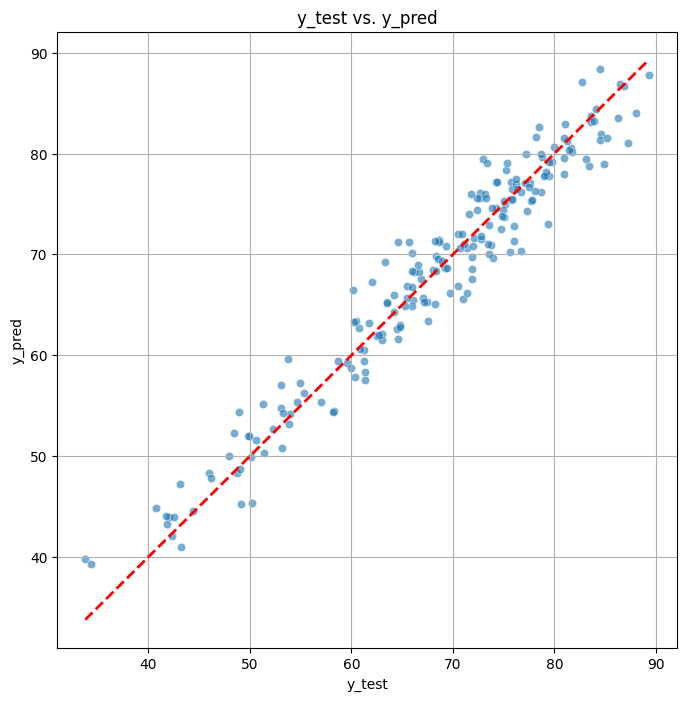

In [50]:
# Visualize actual vs. predicted recovery rates
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test vs. y_pred')
plt.grid(True)
plt.show()

## Feature Importance

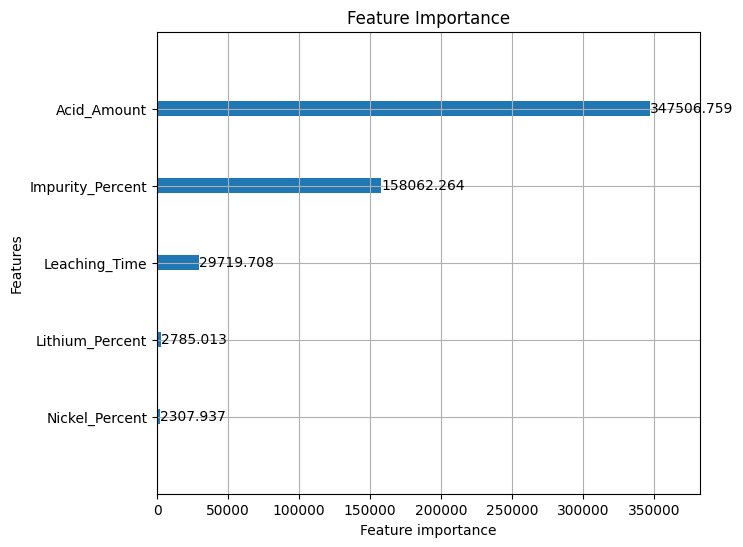

In [51]:
# Plot feature importance
lgb.plot_importance(model, importance_type="gain", figsize=(7,6), title="Feature Importance")
plt.show()

We can see that `Acid_Amount` and `Impurity_Percent` show the highest importance, suggesting they play a dominant role in determining the recovery rate.

# **3. Recommendation of Optimal Process Recipe**

This module aims to recommend an optimal process recipe (a combination of `Nickel_Percent`, `Lithium_Percent`, `Impurity_Percent`, `Acid_Amount`, and `Leaching_Time`) to achieve a desired metal recovery rate. It uses the previously trained LightGBM model to predict recovery rates for various combinations of input parameters and identifies the recipe that yields a predicted recovery rate closest to the target.

## Set target recovery rate

In [52]:
import itertools

# You can change this value
target_recovery_rate = 80

print(f"Target Recovery Rate: {target_recovery_rate}")

Target Recovery Rate: 80


## Define search space

In [53]:
# Define the search space for each feature
nickel_range = np.linspace(df['Nickel_Percent'].min(), df['Nickel_Percent'].max(), 20)
lithium_range = np.linspace(df['Lithium_Percent'].min(), df['Lithium_Percent'].max(), 20)
impurity_range = np.linspace(df['Impurity_Percent'].min(), df['Impurity_Percent'].max(), 20)
acid_range = np.linspace(df['Acid_Amount'].min(), df['Acid_Amount'].max(), 20)
leaching_range = np.linspace(df['Leaching_Time'].min(), df['Leaching_Time'].max(), 20)

# Generate all combinations of parameters
param_combinations = list(itertools.product(nickel_range, lithium_range, impurity_range, acid_range, leaching_range))

print(f"Number of combinations to evaluate: {len(param_combinations)}")

Number of combinations to evaluate: 3200000


- We defined the search space for each feature based on min/max from the original dataset.

- We set the number of steps for each feature to 20 to control the granularity of the grid search.

## Identify optimal process recipe

In [54]:
# Convert combinations to a DataFrame for prediction
param_df = pd.DataFrame(param_combinations, columns=X.columns)

# Predict recovery rates for all combinations
predicted_recovery_rates = model.predict(param_df)

# Find the combination that yields the predicted recovery rate closest to the target
difference = np.abs(predicted_recovery_rates - target_recovery_rate)
closest_index = np.argmin(difference)

best_recipe = param_df.iloc[closest_index]
best_predicted_recovery = predicted_recovery_rates[closest_index]

print(f"Optimal Recipe for Target Recovery Rate ({target_recovery_rate:.6f}):")
print(best_recipe)
print(f"Predicted Recovery Rate for this recipe: {best_predicted_recovery:.6f}")

Optimal Recipe for Target Recovery Rate (80.000000):
Nickel_Percent       53.606787
Lithium_Percent       4.531585
Impurity_Percent     22.101497
Acid_Amount          66.704928
Leaching_Time       151.545248
Name: 1493451, dtype: float64
Predicted Recovery Rate for this recipe: 80.000021


# **4. References**  

- https://github.com/lightgbm-org/LightGBM

- https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

- https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.plot_importance.html

- https://colab.research.google.com/github/pb111/Data-Science-Portfolio-in-Python/blob/master/LightGBM_Classification_Project.ipynb

